In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:

df = pd.read_csv("miniproject.csv")
target='HeartDisease'

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [6]:
df['Cholesterol']=df.groupby(target)['Cholesterol'].transform(lambda x:x.replace(0,x.mean()))

In [7]:
df['RestingBP']=df.groupby(target)['RestingBP'].transform(lambda x:x.replace(0,x.mean()))

In [8]:
df=pd.get_dummies(df,drop_first=True)

In [9]:

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [10]:

df["Cholesterol_ST_Slope_Flat"] = df["Cholesterol"] * df["ST_Slope_Flat"]


df["RestingBP_ST_Slope_Up"] = df["RestingBP"] * df["ST_Slope_Up"]


df["Sex_M_ST_Slope_Flat"] = df["Sex_M"] * df["ST_Slope_Flat"]


df["ChestPainType_ATA_RestingECG_Normal"] = (
    df["ChestPainType_ATA"] * df["RestingECG_Normal"]
)


df["Cholesterol_Sex_M"] = df["Cholesterol"] * df["Sex_M"]


df["Oldpeak_Sex_M"] = df["Oldpeak"] * df["Sex_M"]


df["RestingBP_ST_Slope_Flat"] = df["RestingBP"] * df["ST_Slope_Flat"]


df["Cholesterol_RestingECG_Normal"] = (
    df["Cholesterol"] * df["RestingECG_Normal"]
)


df["Age_Sex_M"] = df["Age"] * df["Sex_M"]


df["RestingBP_MaxHR"] = df["RestingBP"] * df["MaxHR"]

df["Age_MaxHR"] = df["Age"] * df["MaxHR"]


df["ChestPainType_ATA_ST_Slope_Up"] = (
    df["ChestPainType_ATA"] * df["ST_Slope_Up"]
)


df["ChestPainType_NAP_ST_Slope_Up"] = (
    df["ChestPainType_NAP"] * df["ST_Slope_Up"]
)


df["RestingBP_Oldpeak"] = df["RestingBP"] * df["Oldpeak"]


df["RestingBP_Cholesterol"] = df["RestingBP"] * df["Cholesterol"]


df["Oldpeak_ExerciseAngina_Y"] = (
    df["Oldpeak"] * df["ExerciseAngina_Y"]
)


df["Sex_M_ST_Slope_Up"] = df["Sex_M"] * df["ST_Slope_Up"]


df["Sex_M_ST_Slope_Flat"] = df["Sex_M"] * df["ST_Slope_Flat"]


df["Oldpeak_Sex_M"] = df["Oldpeak"] * df["Sex_M"]


df["FastingBS_ST_Slope_Up"] = df["FastingBS"] * df["ST_Slope_Up"]


df["FastingBS_ST_Slope_Flat"] = df["FastingBS"] * df["ST_Slope_Flat"]

In [11]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,...,RestingBP_MaxHR,Age_MaxHR,ChestPainType_ATA_ST_Slope_Up,ChestPainType_NAP_ST_Slope_Up,RestingBP_Oldpeak,RestingBP_Cholesterol,Oldpeak_ExerciseAngina_Y,Sex_M_ST_Slope_Up,FastingBS_ST_Slope_Up,FastingBS_ST_Slope_Flat
0,40,140.0,289.0,0,172,0.0,0,True,True,False,...,24080.0,6880,True,False,0.0,40460.0,0.0,True,0,0
1,49,160.0,180.0,0,156,1.0,1,False,False,True,...,24960.0,7644,False,False,160.0,28800.0,0.0,False,0,0
2,37,130.0,283.0,0,98,0.0,0,True,True,False,...,12740.0,3626,True,False,0.0,36790.0,0.0,True,0,0
3,48,138.0,214.0,0,108,1.5,1,False,False,False,...,14904.0,5184,False,False,207.0,29532.0,1.5,False,0,0
4,54,150.0,195.0,0,122,0.0,0,True,False,True,...,18300.0,6588,False,True,0.0,29250.0,0.0,True,0,0


In [12]:
x=df.drop(target,axis=1)
y=df[target]
feature_names=x.columns

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [14]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [15]:
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train_scaled,y_train)

GradientBoostingClassifier(random_state=42)

In [16]:
explainer=shap.TreeExplainer(gb)
shap_values=explainer.shap_values(x_train_scaled)
importance=np.abs(shap_values).mean(axis=0)
selected_mask=importance >= 0.1
selected_features=feature_names[selected_mask]
print("Selected features")
for f in selected_features:
    print(f)

Selected features
Cholesterol
MaxHR
Oldpeak
ChestPainType_NAP
ExerciseAngina_Y
Cholesterol_ST_Slope_Flat
RestingBP_ST_Slope_Up
ChestPainType_ATA_RestingECG_Normal
Cholesterol_Sex_M
Oldpeak_Sex_M
RestingBP_ST_Slope_Flat
Cholesterol_RestingECG_Normal
RestingBP_MaxHR
Age_MaxHR
ChestPainType_ATA_ST_Slope_Up
RestingBP_Oldpeak
RestingBP_Cholesterol
Oldpeak_ExerciseAngina_Y


In [17]:
x_train_sel=x_train_scaled[:,selected_mask]
x_test_sel=x_test_scaled[:,selected_mask]

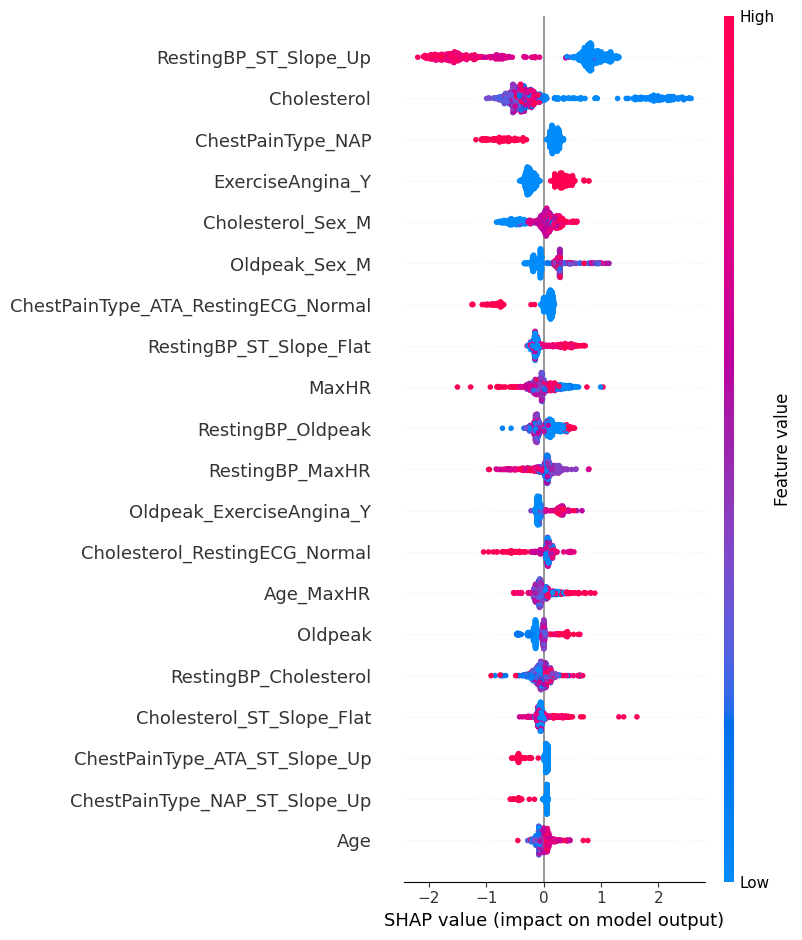

In [18]:
shap.summary_plot(shap_values,x_train_scaled,feature_names=feature_names)

In [19]:
x_train_sel = x_train_scaled[:, selected_mask]
x_test_sel = x_test_scaled[:, selected_mask]

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [25]:
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_sel, y_train)

    y_pred = model.predict(x_test_sel)
    acc = accuracy_score(y_test, y_pred)

    accuracy_scores.append(acc)
best_k=accuracy_scores.index(max(accuracy_scores))
print(best_k)

10


In [26]:
knn = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance',
    metric='euclidean'
)

knn.fit(x_train_sel, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10, weights='distance')

In [27]:
y_pred = knn.predict(x_test_sel)
y_prob = knn.predict_proba(x_test_sel)[:,1]

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8659420289855072
Precision: 0.8717948717948718
Recall: 0.8888888888888888
F1 Score: 0.8802588996763754
ROC AUC: 0.9324087358520645


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       123
           1       0.87      0.89      0.88       153

    accuracy                           0.87       276
   macro avg       0.87      0.86      0.86       276
weighted avg       0.87      0.87      0.87       276



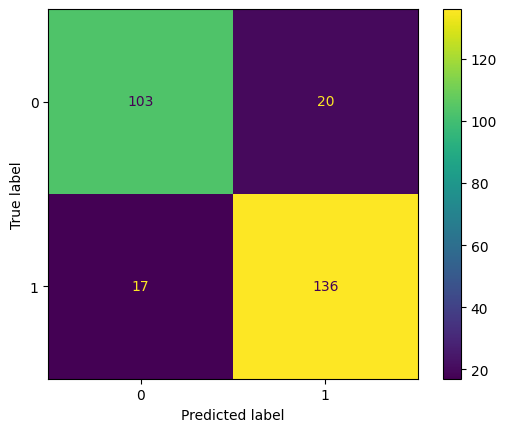

In [30]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()